# Pose Classification using MediaPipe Landmark Detection

In [11]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import json
import seaborn as sns
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report


Epoch 1
-------------------------------
Test Error:
 Accuracy: 82.9%, Avg loss: 0.912333

Epoch 2
-------------------------------
Test Error:
 Accuracy: 85.5%, Avg loss: 0.504608

Epoch 3
-------------------------------
Test Error:
 Accuracy: 84.6%, Avg loss: 0.363567

Epoch 4
-------------------------------
Test Error:
 Accuracy: 86.2%, Avg loss: 0.280697

Epoch 5
-------------------------------
Test Error:
 Accuracy: 86.9%, Avg loss: 0.238776

Epoch 6
-------------------------------
Test Error:
 Accuracy: 89.9%, Avg loss: 0.201052

Epoch 7
-------------------------------
Test Error:
 Accuracy: 92.8%, Avg loss: 0.181962

Epoch 8
-------------------------------
Test Error:
 Accuracy: 94.2%, Avg loss: 0.152148

Epoch 9
-------------------------------
Test Error:
 Accuracy: 94.3%, Avg loss: 0.141598

Epoch 10
-------------------------------
Test Error:
 Accuracy: 94.2%, Avg loss: 0.133367

Epoch 11
-------------------------------
Test Error:
 Accuracy: 94.4%, Avg loss: 0.132570

Epoch 12

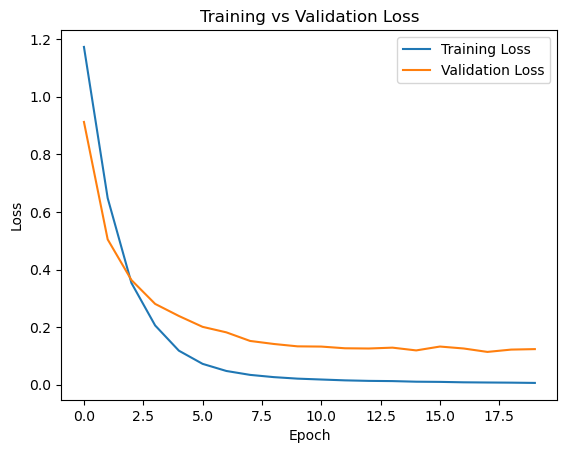

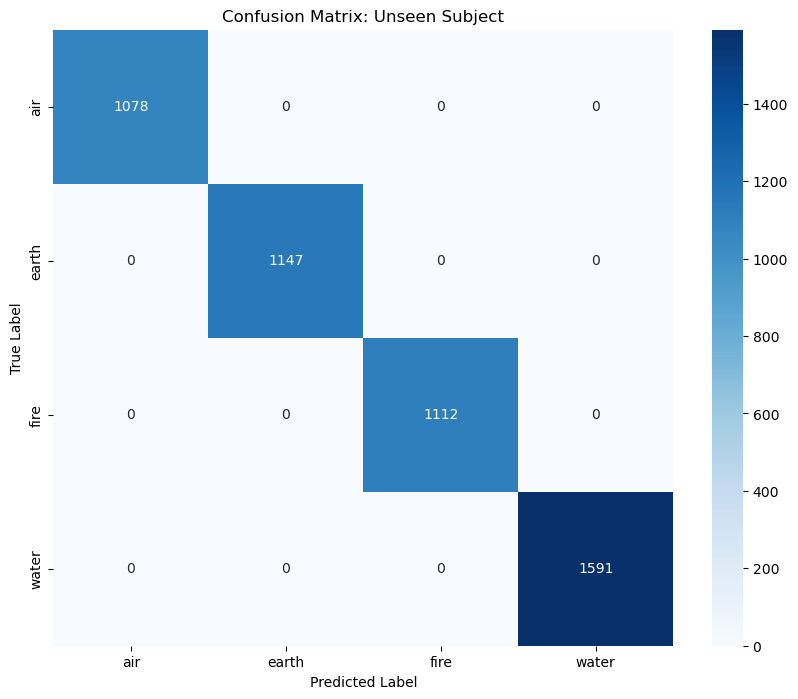

Classification Report:
              precision    recall  f1-score   support

         air       1.00      1.00      1.00      1078
       earth       1.00      1.00      1.00      1147
        fire       1.00      1.00      1.00      1112
       water       1.00      1.00      1.00      1591

    accuracy                           1.00      4928
   macro avg       1.00      1.00      1.00      4928
weighted avg       1.00      1.00      1.00      4928



In [ ]:
def calculate_angle(a, b, c):
    #Helper function to calculate angle between three points (in degrees)
    a, b, c = np.array(a), np.array(b), np.array(c)
    radians = np.arctan2(c[1]-b[1], c[0]-b[0]) - np.arctan2(a[1]-b[1], a[0]-b[0])
    angle = np.abs(radians * 180.0 / np.pi)
    return 360 - angle if angle > 180.0 else angle

def preprocess_pose_data(X_raw):
    # 1. Reshape to (N, 33, 2)
    X = X_raw.reshape(-1, 33, 2)
    N = X.shape[0]

    # 2. Hip Centering (Origin at Hips)
    hip_center = (X[:, 24] + X[:, 23]) / 2
    X = X - hip_center[:, None, :]

    # 3. Torso Scaling (Unit length based on shoulder width/length)
    # Using shoulder center to hip center as the unit of measure
    shoulder_center = (X[:, 12] + X[:, 11]) / 2
    torso_length = np.linalg.norm(shoulder_center, axis=1)
    torso_length = np.maximum(torso_length, 1e-6) # Avoid div by zero
    X = X / torso_length[:, None, None]

    # 4. Feature Engineering: Elbow and Shoulder Angles
    angles = np.zeros((N, 4))
    for i in range(N):
        # Left Elbow: Sh(11), El(13), Wr(15) | Right Elbow: Sh(12), El(14), Wr(16)
        angles[i, 0] = calculate_angle(X[i,11], X[i,13], X[i,15])
        angles[i, 1] = calculate_angle(X[i,12], X[i,14], X[i,16])
        
        # Left Shoulder: Hip(23), Sh(11), El(13) | Right Shoulder: Hip(24), Sh(12), El(14)
        angles[i, 2] = calculate_angle(X[i,23], X[i,11], X[i,13])
        angles[i, 3] = calculate_angle(X[i,24], X[i,12], X[i,14])

    # 5. Flatten coordinates and stack with angles
    X_flat = X.reshape(N, 66)
    return np.hstack([X_flat, angles]) # Shape (N, 70)

#Load the training and validation datasets
train_df1 = pd.read_csv('poseData/four-ppl-data.csv')
train_df2 = pd.read_csv('poseData/dennis-pose-data.csv')
train_df3 = pd.read_csv('poseData/matt-data.csv')
train_df4 = pd.read_csv('poseData/matt2.csv') 
train_df = pd.concat([train_df1, train_df2, train_df3, train_df4], ignore_index=True)

val_df = pd.read_csv('poseData/marek-test.csv')
    
#Data processing and feature engineering
X_train_processed = preprocess_pose_data(train_df.drop('label', axis=1).values)
X_val_processed = preprocess_pose_data(val_df.drop('label', axis=1).values)

#Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_processed)
X_val_scaled = scaler.transform(X_val_processed)

#Label encoding
encoder = LabelEncoder()
y_train = encoder.fit_transform(train_df['label'].values)
y_val = encoder.transform(val_df['label'].values) 

X_train_tensor = torch.tensor(X_train_scaled).float()
y_train_tensor = torch.tensor(y_train).long()

X_val_tensor = torch.tensor(X_val_scaled).float()
y_val_tensor = torch.tensor(y_val).long()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset  = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader  = DataLoader(val_dataset, batch_size=32, shuffle=False)

# GROUP-BASED SPLIT

""" raw_labels = data['label'].values
segment_ids = np.zeros(len(raw_labels), dtype=int)
segment = 0
for i in range(1, len(raw_labels)):
    if raw_labels[i] != raw_labels[i - 1]:
        segment += 1
    segment_ids[i] = segment

# Each cycle has 4 classes
n_classes = len(np.unique(y))
cycle_ids = segment_ids // n_classes

print(f"Total segments: {segment + 1}")
print(f"Total cycles: {cycle_ids.max() + 1}")
print(f"Samples per cycle:")
for c in range(cycle_ids.max() + 1):
    mask = cycle_ids == c
    print(f"  Cycle {c}: {mask.sum()} samples, classes: {dict(zip(*np.unique(y[mask], return_counts=True)))}")

# Use last cycle as test, rest as train
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=cycle_ids))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


# Verify no cycle overlap
train_cycles = set(cycle_ids[train_idx])
test_cycles = set(cycle_ids[test_idx])
print(f"\nTrain cycles: {sorted(train_cycles)}")
print(f"Test cycles:  {sorted(test_cycles)}")
print(f"Overlap: {len(train_cycles & test_cycles)} (should be 0)")


X_train_tensor = torch.tensor(X_train).float()
y_train_tensor = torch.tensor(y_train).long()

X_test_tensor = torch.tensor(X_test).float()
y_test_tensor = torch.tensor(y_test).long()

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32) """

# end of GROUP-BASED SPLIT 


######################################################################################################### 
### TRAIN VAL TEST SPLIT 
### 

# # 1. INITIAL SPLIT (Separate Test set entirely)
# X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# # 2. SECOND SPLIT (Split remaining into Train and Val)
# X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42)

# # 3. PREVENT LEAKAGE: Fit scaler ONLY on training data
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_val = scaler.transform(X_val)
# X_test = scaler.transform(X_test)

# # 4. CONVERT TO TENSORS
# X_train_tensor = torch.tensor(X_train).float()
# y_train_tensor = torch.tensor(y_train).long()
# X_val_tensor = torch.tensor(X_val).float()
# y_val_tensor = torch.tensor(y_val).long()
# X_test_tensor = torch.tensor(X_test).float()
# y_test_tensor = torch.tensor(y_test).long()

# # 5. DATALOADERS
# train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=32, shuffle=True)
# val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=32)
# test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32)

### 
### END: TRAIN VAL TEST SPLIT 
################################################################################################

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# X_train_tensor = torch.tensor(X_train).float()
# y_train_tensor = torch.tensor(y_train).long()

# X_test_tensor = torch.tensor(X_test).float()
# y_test_tensor = torch.tensor(y_test).long()

# train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
# test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader  = DataLoader(test_dataset, batch_size=32)


class PoseClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(70, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.model(x)

model = PoseClassifier()
criterion = nn.CrossEntropyLoss()
learning_rate = lr = 0.00001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
batch_size = 64
epochs = 20

def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    total_loss = 0
    num_batches = len(dataloader)

    for batch, (X, y) in enumerate(dataloader):
        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / num_batches
    return avg_loss


def test_loop(dataloader, model, loss_fn):
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            loss = loss_fn(pred, y)
            test_loss += loss.item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    accuracy = correct / size

    print(f"Test Error:\n Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {test_loss:>8f}\n")
    return test_loss

train_losses = []
test_losses = []

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")

    train_loss = train_loop(train_loader, model, criterion, optimizer)
    test_loss = test_loop(val_loader, model, criterion)

    train_losses.append(train_loss)
    test_losses.append(test_loss)

print("Done!")


plt.plot(train_losses, label="Training Loss")
plt.plot(test_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

#performance evaluation on the test set 
test_df = pd.read_csv("poseData/dennis2.csv")
X_test_processed = preprocess_pose_data(test_df.drop('label', axis=1).values)
X_test_scaled = scaler.transform(X_test_processed)
y_test = encoder.transform(test_df['label'].values)

X_test_tensor = torch.tensor(X_test_scaled).float()
y_test_tensor = torch.tensor(y_test).long()

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)    

y_pred = []
y_true = []
model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        y_pred.extend(torch.argmax(outputs, dim=1).tolist())
        y_true.extend(y_batch.tolist())


class_names = encoder.classes_
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Unseen Subject')
plt.show()




print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

In [13]:
# Exploratory data analysis
# Class distribution 
"""unique, counts = np.unique(y, return_counts=True)
plt.bar(unique, counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.show()"""


'unique, counts = np.unique(y, return_counts=True)\nplt.bar(unique, counts)\nplt.xlabel("Class")\nplt.ylabel("Count")\nplt.title("Class Distribution")\nplt.show()'

In [14]:
# Explore if data is similar ranges
"""feature_names = [col for col in data.columns if col != 'label']
df_scaled = pd.DataFrame(X, columns=feature_names)

df_scaled.hist(bins=30, figsize=(20, 30))
plt.suptitle("Feature Distributions (after normalisation)", y=1.01)
plt.tight_layout()
plt.show()"""

'feature_names = [col for col in data.columns if col != \'label\']\ndf_scaled = pd.DataFrame(X, columns=feature_names)\n\ndf_scaled.hist(bins=30, figsize=(20, 30))\nplt.suptitle("Feature Distributions (after normalisation)", y=1.01)\nplt.tight_layout()\nplt.show()'

In [15]:

# 3. CORRELATION MATRIX — which landmarks are redundant

"""corr = df_scaled.corr()
plt.figure(figsize=(16, 14))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Feature Correlation Matrix (66 landmarks)")
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
high_corr = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.95:
            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))

print(f"\nHighly correlated pairs (|r| > 0.95): {len(high_corr)}")
for f1, f2, r in high_corr[:10]:
    print(f"  {f1} <-> {f2}: {r:.3f}")"""

'corr = df_scaled.corr()\nplt.figure(figsize=(16, 14))\nsns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)\nplt.title("Feature Correlation Matrix (66 landmarks)")\nplt.tight_layout()\nplt.show()\n\n# Flag highly correlated pairs\nhigh_corr = []\nfor i in range(len(corr)):\n    for j in range(i+1, len(corr)):\n        if abs(corr.iloc[i, j]) > 0.95:\n            high_corr.append((corr.columns[i], corr.columns[j], corr.iloc[i, j]))\n\nprint(f"\nHighly correlated pairs (|r| > 0.95): {len(high_corr)}")\nfor f1, f2, r in high_corr[:10]:\n    print(f"  {f1} <-> {f2}: {r:.3f}")'

In [16]:
# 4. PCA

"""from sklearn.decomposition import PCA
class_names = encoder.classes_
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
for c in np.unique(y):
    mask = y == c
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=class_names[c], alpha=0.5, s=15)

plt.legend()
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.title("PCA — 2D Projection of Pose Data")
plt.show()"""

'from sklearn.decomposition import PCA\nclass_names = encoder.classes_\npca = PCA(n_components=2)\nX_2d = pca.fit_transform(X)\n\nplt.figure(figsize=(8, 6))\nfor c in np.unique(y):\n    mask = y == c\n    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=class_names[c], alpha=0.5, s=15)\n\nplt.legend()\nplt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")\nplt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")\nplt.title("PCA — 2D Projection of Pose Data")\nplt.show()'

In [17]:
# 5. SPLIT VERIFICATION - train and test distributions


"""fig, axes = plt.subplots(1, 2, figsize=(12, 4))

unique_tr, counts_tr = np.unique(y_train, return_counts=True)
unique_te, counts_te = np.unique(y_test, return_counts=True)

axes[0].bar(class_names[unique_tr], counts_tr / len(y_train))
axes[0].set_title("Train — Class Proportions")
axes[0].set_ylabel("Proportion")
axes[0].set_ylim(0, 1)

axes[1].bar(class_names[unique_te], counts_te / len(y_test))
axes[1].set_title("Test — Class Proportions")
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Feature distribution comparison (first 6 features)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i in range(6):
    axes[i].hist(X_train[:, i], bins=30, alpha=0.5, label="Train", density=True)
    axes[i].hist(X_test[:, i], bins=30, alpha=0.5, label="Test", density=True)
    axes[i].set_title(feature_names[i])
    axes[i].legend()
plt.suptitle("Train vs Test Feature Distributions")
plt.tight_layout()
plt.show()

# Statistical test
from scipy.stats import ks_2samp
mismatches = 0
for i in range(X_train.shape[1]):
    stat, p_value = ks_2samp(X_train[:, i], X_test[:, i])
    if p_value < 0.05:
        mismatches += 1
print(f"Features with significantly different train/test distributions: {mismatches}/{X_train.shape[1]}")"""

'fig, axes = plt.subplots(1, 2, figsize=(12, 4))\n\nunique_tr, counts_tr = np.unique(y_train, return_counts=True)\nunique_te, counts_te = np.unique(y_test, return_counts=True)\n\naxes[0].bar(class_names[unique_tr], counts_tr / len(y_train))\naxes[0].set_title("Train — Class Proportions")\naxes[0].set_ylabel("Proportion")\naxes[0].set_ylim(0, 1)\n\naxes[1].bar(class_names[unique_te], counts_te / len(y_test))\naxes[1].set_title("Test — Class Proportions")\naxes[1].set_ylabel("Proportion")\naxes[1].set_ylim(0, 1)\n\nplt.tight_layout()\nplt.show()\n\n# Feature distribution comparison (first 6 features)\nfig, axes = plt.subplots(2, 3, figsize=(15, 8))\naxes = axes.flatten()\nfor i in range(6):\n    axes[i].hist(X_train[:, i], bins=30, alpha=0.5, label="Train", density=True)\n    axes[i].hist(X_test[:, i], bins=30, alpha=0.5, label="Test", density=True)\n    axes[i].set_title(feature_names[i])\n    axes[i].legend()\nplt.suptitle("Train vs Test Feature Distributions")\nplt.tight_layout()\nplt

In [18]:
# TEMPORAL LEAKAGE CHECK — similarity of consecutive samples


# Computes distance between consecutive frames in the org data
"""consecutive_dists = np.linalg.norm(X[1:] - X[:-1], axis=1)
random_pairs = np.random.choice(len(X), size=(len(X)-1, 2), replace=True)
random_dists = np.linalg.norm(X[random_pairs[:, 0]] - X[random_pairs[:, 1]], axis=1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(consecutive_dists, bins=50, alpha=0.5, label="Consecutive frames", density=True)
ax.hist(random_dists, bins=50, alpha=0.5, label="Random pairs", density=True)
ax.set_xlabel("Euclidean distance between samples")
ax.set_title("Temporal Correlation Check")
ax.legend()
plt.show()

print(f"Median distance between consecutive frames: {np.median(consecutive_dists):.3f}")
print(f"Median distance between random pairs: {np.median(random_dists):.3f}")
print(f"Ratio: {np.median(random_dists) / np.median(consecutive_dists):.1f}x")"""

'consecutive_dists = np.linalg.norm(X[1:] - X[:-1], axis=1)\nrandom_pairs = np.random.choice(len(X), size=(len(X)-1, 2), replace=True)\nrandom_dists = np.linalg.norm(X[random_pairs[:, 0]] - X[random_pairs[:, 1]], axis=1)\n\nfig, ax = plt.subplots(figsize=(10, 4))\nax.hist(consecutive_dists, bins=50, alpha=0.5, label="Consecutive frames", density=True)\nax.hist(random_dists, bins=50, alpha=0.5, label="Random pairs", density=True)\nax.set_xlabel("Euclidean distance between samples")\nax.set_title("Temporal Correlation Check")\nax.legend()\nplt.show()\n\nprint(f"Median distance between consecutive frames: {np.median(consecutive_dists):.3f}")\nprint(f"Median distance between random pairs: {np.median(random_dists):.3f}")\nprint(f"Ratio: {np.median(random_dists) / np.median(consecutive_dists):.1f}x")'

In [19]:
%pip install -q onnx

Note: you may need to restart the kernel to use updated packages.


In [20]:
class PoseClassifierWithSoftmax(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        self.softmax = nn.Softmax(dim=1)

    def forward(self, x):
        logits = self.base_model(x)
        return self.softmax(logits)

model.eval()

export_model = PoseClassifierWithSoftmax(model)
export_model.eval()

torch.onnx.export(
    export_model,
    torch.randn(1, 70),
    "pose_classifier.onnx",
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}}
)

# scaler and labels export remain the same
scaler_params = {
    "mean": scaler.mean_.tolist(),
    "std": scaler.scale_.tolist()
}
with open("pose_scaler.json", "w") as f:
    json.dump(scaler_params, f)

label_mapping = {}
for i, name in enumerate(encoder.classes_):
    label_mapping[str(i)] = name

with open("pose_labels.json", "w") as f:
    json.dump(label_mapping, f)

print("Exported with softmax baked in — output is now probabilities [0, 1]")
print(f"Labels: {label_mapping}")


Exported with softmax baked in — output is now probabilities [0, 1]
Labels: {'0': 'air', '1': 'earth', '2': 'fire', '3': 'water'}


/var/folders/5m/zjlt3vnd62n0fnjz80xh1v340000gn/T/ipykernel_66085/1883200502.py:16: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
